# 우양 샘플 데이터 발전량 예측 실험

자문전문가님이 제공한 샘플 데이터를 기준으로 발전량 예측 모델을 비교합니다.

목표:
1. 샘플 데이터 로드
2. 전문가 제공 feature 구조 기반 feature 생성
3. LightGBM / XGBoost / LSTM 모델 성능 비교
4. 가장 좋은 모델 선정

In [1335]:
# =========================
# 0. 라이브러리
# =========================
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

## 1. 데이터 불러오기

아래 코드가 현재 폴더에서 `260427_우양...csv` 파일을 자동으로 찾습니다.  
파일명을 바꿨다면 `csv_path`를 직접 수정하면 됩니다.

In [1336]:
# =========================
# 1. 데이터 불러오기
# =========================

csv_candidates = glob.glob("*.csv") + glob.glob("../*.csv") + glob.glob("./data/*.csv")
csv_candidates = [p for p in csv_candidates if "우양" in p or "wooyang" in p.lower()]

if len(csv_candidates) == 0:
    raise FileNotFoundError("우양 CSV 파일을 찾지 못했습니다. 이 노트북과 같은 폴더에 CSV를 넣어주세요.")

csv_path = csv_candidates[0]
print("사용 CSV:", csv_path)

df = pd.read_csv(csv_path, encoding="utf-8-sig")

print("데이터 크기:", df.shape)
print("컬럼 목록:")
print(df.columns.tolist())

df.head()

사용 CSV: 260427_우양_2025년9월25일_2026년4월26일.csv
데이터 크기: (5126, 18)
컬럼 목록:
['V_SITE_ID', 'V_TIME', 'D_PVI_CAPA', 'D_PERIOD_GEN_KWH', 'D_TOT_GEN_KWH', 'D_TEMP', 'D_HUMIDITY', 'D_PRESSURE', 'D_DEW', 'D_UVI', 'D_CLOUDS', 'D_VISIBILITY', 'D_WIND_SPEED', 'D_WIND_DEG', 'V_GPS_Y', 'V_GPS_X', '__SRC__', 'TIME']


,V_SITE_ID,V_TIME,D_PVI_CAPA,D_PERIOD_GEN_KWH,D_TOT_GEN_KWH,D_TEMP,D_HUMIDITY,D_PRESSURE,D_DEW,D_UVI,D_CLOUDS,D_VISIBILITY,D_WIND_SPEED,D_WIND_DEG,V_GPS_Y,V_GPS_X,__SRC__,TIME
0,KR10025001,2025092510,968.375,105.20,463708.13,23.38,94.0,1019.0,22.36,0.0,100.0,6302.0,2.75,183.0,36.037267,126.689885,MASTER,2025092510
1,KR10025001,2025092511,968.375,225.53,463933.66,23.32,93.0,1019.0,22.12,0.0,100.0,10000.0,3.57,182.0,36.037267,126.689885,MASTER,2025092511
2,KR10025001,2025092512,968.375,235.00,464168.66,23.37,92.0,1019.0,22.00,0.0,100.0,10000.0,3.60,182.0,36.037267,126.689885,MASTER,2025092512
3,KR10025001,2025092513,968.375,146.07,464314.73,23.62,91.0,1019.0,22.06,0.0,100.0,10000.0,3.06,197.0,36.037267,126.689885,MASTER,2025092513
4,KR10025001,2025092514,968.375,183.46,464498.19,24.68,84.0,1018.0,21.79,0.0,100.0,10000.0,3.01,219.0,36.037267,126.689885,MASTER,2025092514


## 2. 시간 변환 및 기본 확인

- 예측 대상: `D_PERIOD_GEN_KWH`
- 시간 기준: `TIME` 또는 `V_TIME`

In [1337]:
# =========================
# 1. 데이터 불러오기
# =========================
import pandas as pd
import os

csv_path = "260427_우양_2025년9월25일_2026년4월26일.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"파일이 없습니다: {csv_path}")

print("사용 CSV:", csv_path)

try:
    df = pd.read_csv(csv_path, encoding="utf-8-sig")
except:
    df = pd.read_csv(csv_path, encoding="cp949")

print("데이터 크기:", df.shape)
print("컬럼 목록:")
print(df.columns.tolist())

df.head()

사용 CSV: 260427_우양_2025년9월25일_2026년4월26일.csv
데이터 크기: (5126, 18)
컬럼 목록:
['V_SITE_ID', 'V_TIME', 'D_PVI_CAPA', 'D_PERIOD_GEN_KWH', 'D_TOT_GEN_KWH', 'D_TEMP', 'D_HUMIDITY', 'D_PRESSURE', 'D_DEW', 'D_UVI', 'D_CLOUDS', 'D_VISIBILITY', 'D_WIND_SPEED', 'D_WIND_DEG', 'V_GPS_Y', 'V_GPS_X', '__SRC__', 'TIME']


,V_SITE_ID,V_TIME,D_PVI_CAPA,D_PERIOD_GEN_KWH,D_TOT_GEN_KWH,D_TEMP,D_HUMIDITY,D_PRESSURE,D_DEW,D_UVI,D_CLOUDS,D_VISIBILITY,D_WIND_SPEED,D_WIND_DEG,V_GPS_Y,V_GPS_X,__SRC__,TIME
0,KR10025001,2025092510,968.375,105.20,463708.13,23.38,94.0,1019.0,22.36,0.0,100.0,6302.0,2.75,183.0,36.037267,126.689885,MASTER,2025092510
1,KR10025001,2025092511,968.375,225.53,463933.66,23.32,93.0,1019.0,22.12,0.0,100.0,10000.0,3.57,182.0,36.037267,126.689885,MASTER,2025092511
2,KR10025001,2025092512,968.375,235.00,464168.66,23.37,92.0,1019.0,22.00,0.0,100.0,10000.0,3.60,182.0,36.037267,126.689885,MASTER,2025092512
3,KR10025001,2025092513,968.375,146.07,464314.73,23.62,91.0,1019.0,22.06,0.0,100.0,10000.0,3.06,197.0,36.037267,126.689885,MASTER,2025092513
4,KR10025001,2025092514,968.375,183.46,464498.19,24.68,84.0,1018.0,21.79,0.0,100.0,10000.0,3.01,219.0,36.037267,126.689885,MASTER,2025092514


## 3. 전문가 제공 feature 구조 생성

자문전문가님이 공유해주신 구조:
- 시간/계절: `H_SIN`, `H_COS`, `DOY_SIN`, `DOY_COS`
- 기상: `TEMP`, `HUMI`, `CLOU`, `WISP`, `WIDE_SIN`, `WIDE_COS`
- 태양 기하: `SUN_ELEV_CLIP`, `COS_ZEN`
- 강수: `PCP_MM`, `PCP_6H`, `SNO_24H`, `POP_PCT`
- 결측 플래그: `N_MISSING`, `MISS_TEMP`, `MISS_CLOU`, `MISS_WISP`, `MISS_WIDE`, `MISS_ASOS_ANY`

현재 샘플 데이터에 강수 컬럼이 없으므로 강수 feature는 0으로 대체합니다.

In [1338]:
# =========================
# Feature 생성 (우양 데이터 맞춤)
# =========================

import numpy as np
import pandas as pd

# -------------------------
# 1. 시간 컬럼 변환
# -------------------------
target_col = "D_PERIOD_GEN_KWH"
df["TIME"] = pd.to_datetime(df["V_TIME"].astype(str), format="%Y%m%d%H")
df = df.sort_values("TIME").reset_index(drop=True)

hour = df["TIME"].dt.hour
doy = df["TIME"].dt.dayofyear

# -------------------------
# 2. 설비용량
# -------------------------
df["CAPA"] = df["D_PVI_CAPA"]

# -------------------------
# 3. 시간 / 계절 feature
# -------------------------
df["H_SIN"] = np.sin(2 * np.pi * hour / 24)
df["H_COS"] = np.cos(2 * np.pi * hour / 24)

df["DOY_SIN"] = np.sin(2 * np.pi * doy / 365)
df["DOY_COS"] = np.cos(2 * np.pi * doy / 365)

# -------------------------
# 4. 기상 feature 매핑
# -------------------------
df["TEMP"] = df["D_TEMP"]
df["HUMI"] = df["D_HUMIDITY"]
df["CLOU"] = df["D_CLOUDS"]
df["WISP"] = df["D_WIND_SPEED"]

# -------------------------
# 5. 풍향 sin/cos 변환
# -------------------------
df["WIDE_SIN"] = np.sin(np.deg2rad(df["D_WIND_DEG"]))
df["WIDE_COS"] = np.cos(np.deg2rad(df["D_WIND_DEG"]))

# -------------------------
# 6. 태양 기하 feature
# 현재는 시간 기반 근사값
# -------------------------
df["SUN_ELEV_CLIP"] = np.maximum(0, np.sin(np.pi * (hour - 6) / 12))
df["COS_ZEN"] = df["SUN_ELEV_CLIP"]

# -------------------------
# 7. 일사량 proxy feature
# -------------------------
df["IRRADIANCE_PROXY"] = df["SUN_ELEV_CLIP"]

df["CLEARNESS_PROXY"] = 1 - (df["CLOU"] / 100)
df["CLEARNESS_PROXY"] = df["CLEARNESS_PROXY"].clip(0, 1)

df["EST_IRRADIANCE"] = df["IRRADIANCE_PROXY"] * df["CLEARNESS_PROXY"]
df["IRRADIANCE_X_CAPA"] = df["EST_IRRADIANCE"] * df["CAPA"]

# -------------------------
# 8. 강수 feature
# 현재 데이터에 강수 컬럼이 없으므로 0 처리
# -------------------------
df["PCP_MM"] = 0
df["PCP_6H"] = 0
df["SNO_24H"] = 0
df["POP_PCT"] = 0

# -------------------------
# 9. 발전량 패턴 feature
# -------------------------
df["GEN_NORMAL_PATTERN"] = np.exp(-((df["TIME"].dt.hour - 13) ** 2) / 18)

df["SEASONAL_SOLAR_PATTERN"] = df["GEN_NORMAL_PATTERN"] * df["DOY_SIN"].clip(lower=0)

df["WEATHER_ADJUSTED_PATTERN"] = (
    df["GEN_NORMAL_PATTERN"] * df["CLEARNESS_PROXY"]
)

df["EXPECTED_GEN_PROXY"] = (
    df["WEATHER_ADJUSTED_PATTERN"] * df["CAPA"]
)

df["GEN_LAG_1"] = df[target_col].shift(1)
df["GEN_LAG_2"] = df[target_col].shift(2)
df["GEN_LAG_3"] = df[target_col].shift(3)

df["GEN_ROLL_MEAN_3"] = df[target_col].shift(1).rolling(3).mean()
df["GEN_ROLL_MEAN_6"] = df[target_col].shift(1).rolling(6).mean()

# -------------------------
# 10. 결측 플래그 생성
# -------------------------
df["MISS_TEMP"] = df["D_TEMP"].isna().astype(int)
df["MISS_CLOU"] = df["D_CLOUDS"].isna().astype(int)
df["MISS_WISP"] = df["D_WIND_SPEED"].isna().astype(int)
df["MISS_WIDE"] = df["D_WIND_DEG"].isna().astype(int)

df["N_MISSING"] = df[
    ["MISS_TEMP", "MISS_CLOU", "MISS_WISP", "MISS_WIDE"]
].sum(axis=1)

df["MISS_ASOS_ANY"] = (df["N_MISSING"] > 0).astype(int)

# -------------------------
# 11. 확인
# -------------------------
print("Feature 생성 완료")

check_cols = [
    "TIME",
    "H_SIN", "H_COS", "DOY_SIN", "DOY_COS",
    "TEMP", "HUMI", "CLOU", "WISP",
    "WIDE_SIN", "WIDE_COS",
    "SUN_ELEV_CLIP", "COS_ZEN",
    "IRRADIANCE_PROXY", "CLEARNESS_PROXY",
    "EST_IRRADIANCE", "IRRADIANCE_X_CAPA",
    "GEN_NORMAL_PATTERN", "WEATHER_ADJUSTED_PATTERN",
    "EXPECTED_GEN_PROXY",
    "N_MISSING", "MISS_ASOS_ANY",
    "CAPA"
]

print(df[check_cols].head())
print("총 생성 feature 수:", len(check_cols) - 1)

Feature 생성 완료
                 TIME         H_SIN     H_COS   DOY_SIN  DOY_COS   TEMP  HUMI  \
0 2025-09-25 10:00:00  5.000000e-01 -0.866025 -0.995105 -0.09882  23.38  94.0   
1 2025-09-25 11:00:00  2.588190e-01 -0.965926 -0.995105 -0.09882  23.32  93.0   
2 2025-09-25 12:00:00  1.224647e-16 -1.000000 -0.995105 -0.09882  23.37  92.0   
3 2025-09-25 13:00:00 -2.588190e-01 -0.965926 -0.995105 -0.09882  23.62  91.0   
4 2025-09-25 14:00:00 -5.000000e-01 -0.866025 -0.995105 -0.09882  24.68  84.0   

    CLOU  WISP  WIDE_SIN  ...  IRRADIANCE_PROXY  CLEARNESS_PROXY  \
0  100.0  2.75 -0.052336  ...          0.866025              0.0   
1  100.0  3.57 -0.034899  ...          0.965926              0.0   
2  100.0  3.60 -0.034899  ...          1.000000              0.0   
3  100.0  3.06 -0.292372  ...          0.965926              0.0   
4  100.0  3.01 -0.629320  ...          0.866025              0.0   

   EST_IRRADIANCE  IRRADIANCE_X_CAPA  GEN_NORMAL_PATTERN  \
0             0.0             

In [1339]:
# =========================
# NASA 일사량 추가 - 시간 미스매치 보정 버전
# =========================

import requests
import pandas as pd

lat = 36.0185
lon = 126.6953

start_date = df["TIME"].min().strftime("%Y%m%d")
end_date = df["TIME"].max().strftime("%Y%m%d")

url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    f"?parameters=ALLSKY_SFC_SW_DWN"
    f"&community=RE"
    f"&longitude={lon}"
    f"&latitude={lat}"
    f"&start={start_date}"
    f"&end={end_date}"
    f"&format=JSON"
    f"&time-standard=UTC"
)

res = requests.get(url)
data = res.json()

irr = data["properties"]["parameter"]["ALLSKY_SFC_SW_DWN"]

df_irr = pd.DataFrame(list(irr.items()), columns=["TIME_KEY", "IRRADIANCE"])

# NASA UTC 시간으로 파싱
df_irr["TIME_UTC"] = pd.to_datetime(df_irr["TIME_KEY"], format="%Y%m%d%H", utc=True)

# UTC → 한국시간 변환
df_irr["TIME"] = df_irr["TIME_UTC"].dt.tz_convert("Asia/Seoul").dt.tz_localize(None)

df_irr = df_irr[["TIME", "IRRADIANCE"]]

# 결측/이상값 처리
df_irr["IRRADIANCE"] = df_irr["IRRADIANCE"].replace(-999, 0)
df_irr["IRRADIANCE"] = df_irr["IRRADIANCE"].fillna(0)

# IRRADIANCE 시간 1시간 shift
df_irr["TIME"] = df_irr["TIME"] + pd.Timedelta(hours=1)

df = df.drop(columns=["IRRADIANCE"], errors="ignore")

# 다시 merge
df = df.merge(
    df_irr[["TIME", "IRRADIANCE"]],
    on="TIME",
    how="left"
)

df["IRRADIANCE"] = df["IRRADIANCE"].fillna(0)

print(df[["TIME", "IRRADIANCE"]].head(10))
print("IRRADIANCE 결측:", df["IRRADIANCE"].isna().sum())

                 TIME  IRRADIANCE
0 2025-09-25 10:00:00      101.25
1 2025-09-25 11:00:00      159.32
2 2025-09-25 12:00:00      238.85
3 2025-09-25 13:00:00      197.70
4 2025-09-25 14:00:00      369.58
5 2025-09-25 15:00:00      338.83
6 2025-09-25 16:00:00      294.20
7 2025-09-25 17:00:00      164.50
8 2025-09-25 18:00:00       58.92
9 2025-09-25 19:00:00        3.35
IRRADIANCE 결측: 0


In [1340]:
print("df TIME")
print(df["TIME"].head(5))

print("\ndf_irr TIME")
print(df_irr["TIME"].head(5))

df[["TIME", "IRRADIANCE"]].iloc[100:120]

df[["TIME", "IRRADIANCE"]].head(50)

df TIME
0   2025-09-25 10:00:00
1   2025-09-25 11:00:00
2   2025-09-25 12:00:00
3   2025-09-25 13:00:00
4   2025-09-25 14:00:00
Name: TIME, dtype: datetime64[ns]

df_irr TIME
0   2025-09-25 10:00:00
1   2025-09-25 11:00:00
2   2025-09-25 12:00:00
3   2025-09-25 13:00:00
4   2025-09-25 14:00:00
Name: TIME, dtype: datetime64[ns]


,TIME,IRRADIANCE
0,2025-09-25 10:00:00,101.25
1,2025-09-25 11:00:00,159.32
2,2025-09-25 12:00:00,238.85
3,2025-09-25 13:00:00,197.70
4,2025-09-25 14:00:00,369.58
5,2025-09-25 15:00:00,338.83
6,2025-09-25 16:00:00,294.20
7,2025-09-25 17:00:00,164.50
8,2025-09-25 18:00:00,58.92
9,2025-09-25 19:00:00,3.35


In [1341]:
print(df["TIME"].min(), df["TIME"].max())
print(df_irr["TIME"].min(), df_irr["TIME"].max())

2025-09-25 10:00:00 2026-04-26 23:00:00
2025-09-25 10:00:00 2026-04-27 09:00:00


In [1342]:
# =========================
# 발전량 이상치 제거 - 비교용 df_clip 생성
# =========================

df_clip = df.copy()

target_col = "D_PERIOD_GEN_KWH"

lower = df_clip[target_col].quantile(0.01)
upper = df_clip[target_col].quantile(0.99)

df_clip[target_col] = df_clip[target_col].clip(lower=lower, upper=upper)

print("df_clip 생성 완료")

df_clip 생성 완료


## 4. Feature / Target 설정

이번 실험은 전문가 feature 구조를 우선으로 사용합니다.  
`CAPA`는 발전소 설비 용량 정보로 추가했습니다.

In [1343]:
# =========================
# Final Feature 23
# =========================

feature_cols_23 = [

    # 시간 / 주기
    "H_SIN", "H_COS",
    "DOY_SIN", "DOY_COS",

    # 기상
    "TEMP", "HUMI", "CLOU", "WISP",
    "WIDE_SIN", "WIDE_COS",

    # 태양 위치
    "SUN_ELEV_CLIP", "COS_ZEN",

    # 일사량
    "IRRADIANCE",
    "EST_IRRADIANCE",
    "IRRADIANCE_PROXY",
    "IRRADIANCE_X_CAPA",

    # 설비 용량
    "CAPA",

    # 계절 / 패턴
    "SEASONAL_SOLAR_PATTERN",
    "WEATHER_ADJUSTED_PATTERN",
    "EXPECTED_GEN_PROXY",

    # 발전량 lag
    "GEN_LAG_2"
    
    

    # rolling
    
]

print("feature 개수:", len(feature_cols_23))

feature 개수: 21


In [1344]:
# =========================
# 모델 데이터 생성
# =========================

target_col = "D_PERIOD_GEN_KWH"

df_model = df_clip[
    ["TIME"] + feature_cols_23 + [target_col]
].copy()

# target 결측 제거
df_model = df_model.dropna(
    subset=[target_col]
).reset_index(drop=True)

# feature 결측 처리
for col in feature_cols_23:
    df_model[col] = df_model[col].fillna(
        df_model[col].median()
    )

X = df_model[feature_cols_23]
y = df_model[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5126, 21)
y shape: (5126,)


In [1345]:
# =========================
# 4. Feature / Target 설정
# =========================


df["IRRADIANCE"] = df["IRRADIANCE"].fillna(0)

feature_cols = [
    # 시간/계절
    "H_SIN", "H_COS", "DOY_SIN", "DOY_COS",

    # 기상
    "TEMP", "HUMI", "CLOU", "WISP",
    "WIDE_SIN", "WIDE_COS",

    # 태양
    "SUN_ELEV_CLIP", "COS_ZEN",

    # 강수
    "PCP_MM", "PCP_6H", "SNO_24H", "POP_PCT",

    # 결측
    "N_MISSING", "MISS_TEMP", "MISS_CLOU",
    "MISS_WISP", "MISS_WIDE", "MISS_ASOS_ANY",

    # 설비
    "CAPA",

    # 일사량 proxy
    "IRRADIANCE_PROXY",
    "CLEARNESS_PROXY",
    "EST_IRRADIANCE",
    "IRRADIANCE_X_CAPA",

    # 발전 패턴
    "GEN_NORMAL_PATTERN",
    "SEASONAL_SOLAR_PATTERN",
    "WEATHER_ADJUSTED_PATTERN",
    "EXPECTED_GEN_PROXY",

    "IRRADIANCE",

    "GEN_LAG_1",
    "GEN_LAG_2",
    "GEN_LAG_3",
    "GEN_ROLL_MEAN_3",
    "GEN_ROLL_MEAN_6",
]

df_model = df_clip[["TIME"] + feature_cols_23 + [target_col]].copy()

df_model = df_model.dropna(subset=[target_col]).reset_index(drop=True)

for col in feature_cols_23:
    df_model[col] = df_model[col].fillna(df_model[col].median())

X = df_model[feature_cols_23]
y = df_model[target_col]

print("X:", X.shape)
print("y:", y.shape)

X: (5126, 21)
y: (5126,)


In [1346]:
print(df.columns)

Index(['V_SITE_ID', 'V_TIME', 'D_PVI_CAPA', 'D_PERIOD_GEN_KWH',
       'D_TOT_GEN_KWH', 'D_TEMP', 'D_HUMIDITY', 'D_PRESSURE', 'D_DEW', 'D_UVI',
       'D_CLOUDS', 'D_VISIBILITY', 'D_WIND_SPEED', 'D_WIND_DEG', 'V_GPS_Y',
       'V_GPS_X', '__SRC__', 'TIME', 'CAPA', 'H_SIN', 'H_COS', 'DOY_SIN',
       'DOY_COS', 'TEMP', 'HUMI', 'CLOU', 'WISP', 'WIDE_SIN', 'WIDE_COS',
       'SUN_ELEV_CLIP', 'COS_ZEN', 'IRRADIANCE_PROXY', 'CLEARNESS_PROXY',
       'EST_IRRADIANCE', 'IRRADIANCE_X_CAPA', 'PCP_MM', 'PCP_6H', 'SNO_24H',
       'POP_PCT', 'GEN_NORMAL_PATTERN', 'SEASONAL_SOLAR_PATTERN',
       'WEATHER_ADJUSTED_PATTERN', 'EXPECTED_GEN_PROXY', 'GEN_LAG_1',
       'GEN_LAG_2', 'GEN_LAG_3', 'GEN_ROLL_MEAN_3', 'GEN_ROLL_MEAN_6',
       'MISS_TEMP', 'MISS_CLOU', 'MISS_WISP', 'MISS_WIDE', 'N_MISSING',
       'MISS_ASOS_ANY', 'IRRADIANCE'],
      dtype='object')


In [1347]:
# =========================
# 5. 분포 불일치 대응용 데이터 증강
# =========================

#df_aug = df_model.copy()

#np.random.seed(42)

# -------------------------
# 1. 예보 오차 시뮬레이션
# -------------------------

# 온도 예보 오차
#df_aug["TEMP"] = df_aug["TEMP"] + np.random.normal(0, 1.0, len(df_aug))

# 습도 예보 오차
#df_aug["HUMI"] = df_aug["HUMI"] + np.random.normal(0, 5.0, len(df_aug))

# 운량 예보 오차
#df_aug["CLOU"] = df_aug["CLOU"] + np.random.normal(0, 10.0, len(df_aug))

# 풍속 예보 오차
#df_aug["WISP"] = df_aug["WISP"] + np.random.normal(0, 0.8, len(df_aug))

# 값 범위 보정
#df_aug["HUMI"] = df_aug["HUMI"].clip(0, 100)
#df_aug["CLOU"] = df_aug["CLOU"].clip(0, 100)
#df_aug["WISP"] = df_aug["WISP"].clip(lower=0)

# -------------------------
# 2. 예보 결측 상황 시뮬레이션
# -------------------------

#missing_rate = 0.05

#for col, flag_col in [
   # ("TEMP", "MISS_TEMP"),
  #  ("CLOU", "MISS_CLOU"),
 #   ("WISP", "MISS_WISP"),
#]:
 #   mask = np.random.rand(len(df_aug)) < missing_rate
  #  df_aug.loc[mask, col] = np.nan
   # df_aug.loc[mask, flag_col] = 1

# 결측 개수 다시 계산
#df_aug["N_MISSING"] = df_aug[
 #   ["MISS_TEMP", "MISS_CLOU", "MISS_WISP", "MISS_WIDE"]
#].sum(axis=1)

#df_aug["MISS_ASOS_ANY"] = (df_aug["N_MISSING"] > 0).astype(int)

# -------------------------
# 3. 결측값 보정
# -------------------------
#for col in ["TEMP", "HUMI", "CLOU", "WISP"]:
 #   df_aug[col] = df_aug[col].fillna(df_aug[col].median())

# -------------------------
# 4. 증강 데이터 기준 X, y 생성
# -------------------------

#X_aug = df_aug[feature_cols]
#y_aug = df_aug[target_col]

#print("분포 불일치 대응 데이터 생성 완료")
#print("X_aug:", X_aug.shape)
#print("y_aug:", y_aug.shape)
#print("결측 개수:", X_aug.isna().sum().sum())

## 5. 시간 순서 기준 Train/Test 분할

시계열 데이터이므로 랜덤 분할이 아니라 앞 80%를 학습, 뒤 20%를 테스트로 사용합니다.

In [1348]:
# 패널 feature 개수에 맞춤
df_model_cut = df_model.iloc[:3640]

X = df_model_cut[feature_cols_23]
y = df_model_cut[target_col]

# 분리
X_train = X.iloc[:2898]
X_val = X.iloc[2898:2898+409]
X_test = X.iloc[2898+409:]

y_train = y.iloc[:2898]
y_val = y.iloc[2898:2898+409]
y_test = y.iloc[2898+409:]

In [1349]:

panel_train = pd.read_csv("panel_features_train.csv")
panel_val = pd.read_csv("panel_features_val.csv")
panel_test = pd.read_csv("panel_features_test.csv")



# image 컬럼 제거
panel_train = panel_train.drop(columns=["image"], errors="ignore")
panel_val = panel_val.drop(columns=["image"], errors="ignore")
panel_test = panel_test.drop(columns=["image"], errors="ignore")

# 패널 feature 결합
X_train_final = pd.concat(
    [X_train.reset_index(drop=True),
     panel_train.reset_index(drop=True)],
    axis=1
)

X_val_final = pd.concat(
    [X_val.reset_index(drop=True),
     panel_val.reset_index(drop=True)],
    axis=1
)

X_test_final = pd.concat(
    [X_test.reset_index(drop=True),
     panel_test.reset_index(drop=True)],
    axis=1
)

print(X_train_final.shape)
print(X_val_final.shape)
print(X_test_final.shape)

(2898, 31)
(409, 31)
(333, 31)


In [1350]:
# =========================
# Wooyang test 데이터 저장
# =========================

wooyang_test_df = X_test_final.copy()

# TIME도 동일한 333개 구간으로 맞춤
time_test = df_model_cut["TIME"].iloc[2898+409:]

wooyang_test_df.insert(0, "TIME", time_test.values)

# 실제값 포함
wooyang_test_df["ACTUAL_GEN_KWH"] = y_test.values

# 저장
wooyang_test_df.to_csv(
    "wooyang_test_data_panel.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ wooyang_test_data_panel.csv 저장 완료")
print(wooyang_test_df.shape)

✅ wooyang_test_data_panel.csv 저장 완료
(333, 33)


In [1351]:
# ==========================
# 전체 데이터 CSV 저장 (백엔드 전달용)
# ==========================

# train + val + test 합치기
X_full = pd.concat(
    [X_train_final, X_val_final, X_test_final],
    axis=0
).reset_index(drop=True)

# 실제값도 합치기
y_full = pd.concat(
    [y_train, y_val, y_test],
    axis=0
).reset_index(drop=True)

# CSV 생성
merged_full_df = X_full.copy()

# TIME 붙이기
merged_full_df.insert(0, "TIME", df_model_cut["TIME"].values)

# 예측값
merged_full_df["PREDICTION"] = lgb_model.predict(X_full)

# 실제값
merged_full_df["ACTUAL"] = y_full.values

# 저장
merged_full_df.to_csv(
    "wooyang_merged_result_full.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ 저장 완료")
print(merged_full_df.shape)
print(merged_full_df.head())

✅ 저장 완료
(3640, 34)
                 TIME         H_SIN     H_COS   DOY_SIN  DOY_COS   TEMP  HUMI  \
0 2025-09-25 10:00:00  5.000000e-01 -0.866025 -0.995105 -0.09882  23.38  94.0   
1 2025-09-25 11:00:00  2.588190e-01 -0.965926 -0.995105 -0.09882  23.32  93.0   
2 2025-09-25 12:00:00  1.224647e-16 -1.000000 -0.995105 -0.09882  23.37  92.0   
3 2025-09-25 13:00:00 -2.588190e-01 -0.965926 -0.995105 -0.09882  23.62  91.0   
4 2025-09-25 14:00:00 -5.000000e-01 -0.866025 -0.995105 -0.09882  24.68  84.0   

    CLOU  WISP  WIDE_SIN  ...  bird_dropping_count  physical_damage_count  \
0  100.0  2.75 -0.052336  ...             2.207460              -0.069065   
1  100.0  3.57 -0.034899  ...            -0.131346               2.435945   
2  100.0  3.60 -0.034899  ...            -0.131346               2.435945   
3  100.0  3.06 -0.292372  ...            -0.131346               2.435945   
4  100.0  3.01 -0.629320  ...            -0.131346              -0.069065   

   max_defect_confidence  cls_n

In [1352]:
print(merged_full_df["TIME"].min())
print(merged_full_df["TIME"].max())
print(len(merged_full_df))

print("결측치 개수:", merged_full_df.isnull().sum().sum())
print("컬럼 개수:", len(merged_full_df.columns))

2025-09-25 10:00:00
2026-02-24 01:00:00
3640
결측치 개수: 0
컬럼 개수: 34


In [1353]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(random_state=42)

# 패널 feature 포함 데이터로 재학습
lgb_model.fit(X_train_final, y_train)

# 검증 성능 확인
val_pred_lgb = lgb_model.predict(X_val_final)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_lgb))
val_mae = mean_absolute_error(y_val, val_pred_lgb)

print("Validation RMSE:", val_rmse)
print("Validation MAE:", val_mae)

Validation RMSE: 90.52478425184827
Validation MAE: 45.11697485693452


In [1354]:
# =========================
# test 데이터 / merged 결과 재생성
# =========================

# test 구간 TIME 333개로 맞추기
time_test = df_model_cut["TIME"].iloc[2898+409:]

# 예측값도 X_test_final 기준으로 다시 생성
y_pred_lgb = lgb_model.predict(X_test_final)

# test 데이터 저장
wooyang_test_df = X_test_final.copy()
wooyang_test_df.insert(0, "TIME", time_test.values)

wooyang_test_df.to_csv(
    "wooyang_test_data_panel.csv",
    index=False,
    encoding="utf-8-sig"
)

# 예측 + 실제값 포함 결과 저장
merged_df = X_test_final.copy()
merged_df.insert(0, "TIME", time_test.values)
merged_df["PREDICTION"] = y_pred_lgb
merged_df["ACTUAL"] = y_test.values

merged_df.to_csv(
    "wooyang_merged_result_panel.csv",
    index=False,
    encoding="utf-8-sig"
)

print("재생성 완료")
print("X_test_final:", X_test_final.shape)
print("time_test:", len(time_test))
print("prediction:", len(y_pred_lgb))
print("merged:", merged_df.shape)

재생성 완료
X_test_final: (333, 31)
time_test: 333
prediction: 333
merged: (333, 34)


In [1355]:
# =========================
# 1.2 패널별 발전량 이상 감지
# =========================

# 1) 예측 오차 계산
merged_df["ERROR"] = abs(
    merged_df["ACTUAL"] - merged_df["PREDICTION"]
)

# 2) 이상 기준값 설정
threshold = (
    merged_df["ERROR"].mean()
    + 2 * merged_df["ERROR"].std()
)

# 3) 이상 라벨 생성
merged_df["ANOMALY"] = (
    merged_df["ERROR"] > threshold
).astype(int)

print("Threshold:", threshold)
print(merged_df["ANOMALY"].value_counts())

Threshold: 213.78158351836504
ANOMALY
0    310
1     23
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

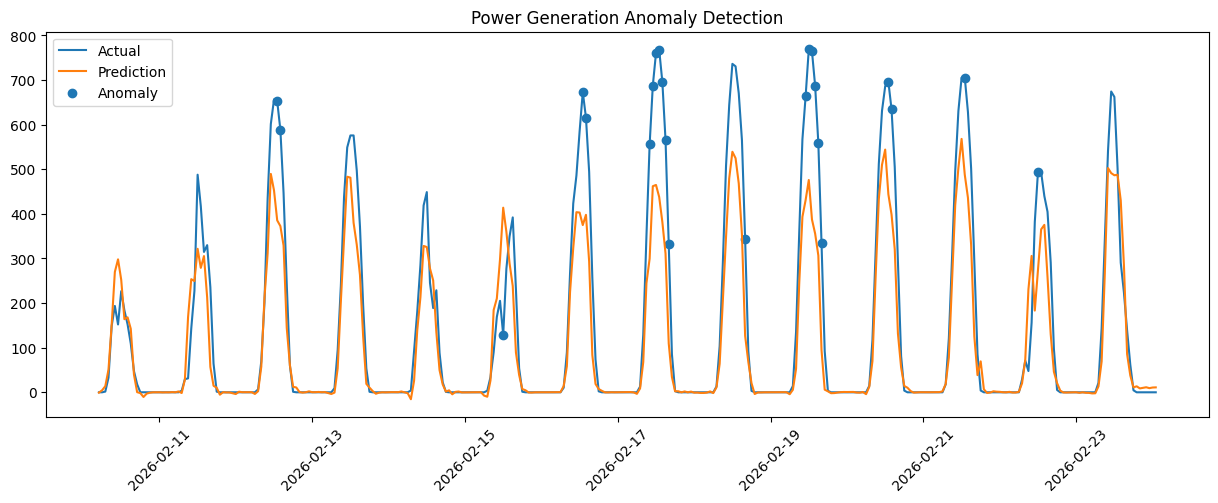

In [1356]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(merged_df["TIME"], merged_df["ACTUAL"], label="Actual")
plt.plot(merged_df["TIME"], merged_df["PREDICTION"], label="Prediction")

anomaly_df = merged_df[merged_df["ANOMALY"] == 1]

plt.scatter(
    anomaly_df["TIME"],
    anomaly_df["ACTUAL"],
    label="Anomaly"
)

plt.legend()
plt.xticks(rotation=45)
plt.title("Power Generation Anomaly Detection")
plt.show()

In [1357]:
panel_cols = [
    "dust_coverage_ratio",
    "snow_coverage_ratio",
    "bird_dropping_count",
    "physical_damage_count",
    "max_defect_confidence",
    "cls_normal",
    "cls_dust",
    "cls_snow",
    "cls_bird",
    "cls_damage"
] 

anomaly_analysis = merged_df.groupby("ANOMALY")[panel_cols].mean()

display(anomaly_analysis)

,dust_coverage_ratio,snow_coverage_ratio,bird_dropping_count,physical_damage_count,max_defect_confidence,cls_normal,cls_dust,cls_snow,cls_bird,cls_damage
ANOMALY,,,,,,,,,,
0,0.033836,0.010983,-0.019121,0.038408,0.460767,0.0,0.200000,0.041935,0.003226,0.287097
1,0.027639,0.000000,-0.131346,0.007174,0.369423,0.0,0.173913,0.000000,0.000000,0.260870


In [1358]:
merged_df.to_csv(
    "wooyang_anomaly_result_panel.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ wooyang_anomaly_result_panel.csv 저장 완료")
print(merged_df.shape)

✅ wooyang_anomaly_result_panel.csv 저장 완료
(333, 36)


In [1359]:
anomaly_only = merged_df[merged_df["ANOMALY"] == 1][
    ["TIME", "ACTUAL", "PREDICTION", "ERROR"]
].sort_values("ERROR", ascending=False)

display(anomaly_only.head(20))

,TIME,ACTUAL,PREDICTION,ERROR
224,2026-02-19 13:00:00,764.37,387.388526,376.981474
225,2026-02-19 14:00:00,686.54,355.571235,330.968765
176,2026-02-17 13:00:00,768.08,437.920690,330.159310
177,2026-02-17 14:00:00,695.54,381.606115,313.933885
152,2026-02-16 13:00:00,673.16,374.928647,298.231353
175,2026-02-17 12:00:00,760.53,464.851192,295.678808
223,2026-02-19 12:00:00,769.17,475.958732,293.211268
127,2026-02-15 12:00:00,128.79,413.894160,285.104160
56,2026-02-12 13:00:00,653.00,385.511403,267.488597
173,2026-02-17 10:00:00,555.58,299.534490,256.045510


In [1360]:
anomaly_only.to_csv(
    "wooyang_anomaly_top20_panel.csv",
    index=False,
    encoding="utf-8-sig"
)

In [1361]:
# =========================
# Classification 기반 이상 감지 고도화
# =========================

from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1) 분류용 입력/정답 생성
X_cls = merged_df.drop(
    columns=["TIME", "ACTUAL", "PREDICTION", "ERROR", "ANOMALY"],
    errors="ignore"
)

y_cls = merged_df["ANOMALY"]

# 2) 시계열 순서 유지 분할
split_idx = int(len(X_cls) * 0.8)

X_cls_train = X_cls.iloc[:split_idx]
X_cls_test = X_cls.iloc[split_idx:]

y_cls_train = y_cls.iloc[:split_idx]
y_cls_test = y_cls.iloc[split_idx:]

# 3) 분류 모델 학습
clf_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=5,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

clf_model.fit(X_cls_train, y_cls_train)

# 4) 이상 여부 예측
y_cls_pred = clf_model.predict(X_cls_test)

# 5) 성능 평가
print("Accuracy:", accuracy_score(y_cls_test, y_cls_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_cls_test, y_cls_pred))
print("\nClassification Report")
print(classification_report(y_cls_test, y_cls_pred))

Accuracy: 0.9104477611940298

Confusion Matrix
[[60  5]
 [ 1  1]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        65
           1       0.17      0.50      0.25         2

    accuracy                           0.91        67
   macro avg       0.58      0.71      0.60        67
weighted avg       0.96      0.91      0.93        67



In [1362]:
# =========================
# Classification 결과 저장
# =========================

cls_result_df = merged_df.iloc[split_idx:].copy()
cls_result_df["CLS_ANOMALY_PRED"] = y_cls_pred

cls_result_df.to_csv(
    "wooyang_anomaly_classification_result.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ wooyang_anomaly_classification_result.csv 저장 완료")
print(cls_result_df.shape)

✅ wooyang_anomaly_classification_result.csv 저장 완료
(67, 37)


In [1363]:
# =========================
# Hybrid 이상 감지 결과 생성
# Regression + Classification
# =========================

hybrid_df = cls_result_df.copy()

# Regression 기반 이상 라벨
# 기존 ANOMALY 컬럼 사용

# Classification 기반 이상 라벨
# CLS_ANOMALY_PRED 컬럼 사용

hybrid_df["HYBRID_ANOMALY"] = (
    (hybrid_df["ANOMALY"] == 1) |
    (hybrid_df["CLS_ANOMALY_PRED"] == 1)
).astype(int)

print(hybrid_df["HYBRID_ANOMALY"].value_counts())

display(
    hybrid_df[
        ["TIME", "ACTUAL", "PREDICTION", "ERROR", 
         "ANOMALY", "CLS_ANOMALY_PRED", "HYBRID_ANOMALY"]
    ].head(20)
)

HYBRID_ANOMALY
0    60
1     7
Name: count, dtype: int64


,TIME,ACTUAL,PREDICTION,ERROR,ANOMALY,CLS_ANOMALY_PRED,HYBRID_ANOMALY
266,2026-02-21 07:00:00,17.69,18.467022,0.777022,0,0,0
267,2026-02-21 08:00:00,120.78,78.103174,42.676826,0,0,0
268,2026-02-21 09:00:00,300.77,251.383144,49.386856,0,0,0
269,2026-02-21 10:00:00,495.88,419.604711,76.275289,0,0,0
270,2026-02-21 11:00:00,630.73,502.979625,127.750375,0,0,0
271,2026-02-21 12:00:00,705.29,568.130508,137.159492,0,0,0
272,2026-02-21 13:00:00,705.75,487.969173,217.780827,1,1,1
273,2026-02-21 14:00:00,628.30,436.116013,192.183987,0,0,0
274,2026-02-21 15:00:00,501.58,330.646763,170.933237,0,0,0
275,2026-02-21 16:00:00,296.20,125.489950,170.710050,0,0,0


In [1364]:
hybrid_df.to_csv(
    "wooyang_hybrid_anomaly_result.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ wooyang_hybrid_anomaly_result.csv 저장 완료")
print(hybrid_df.shape)

✅ wooyang_hybrid_anomaly_result.csv 저장 완료
(67, 38)


In [1365]:
!pip install shap

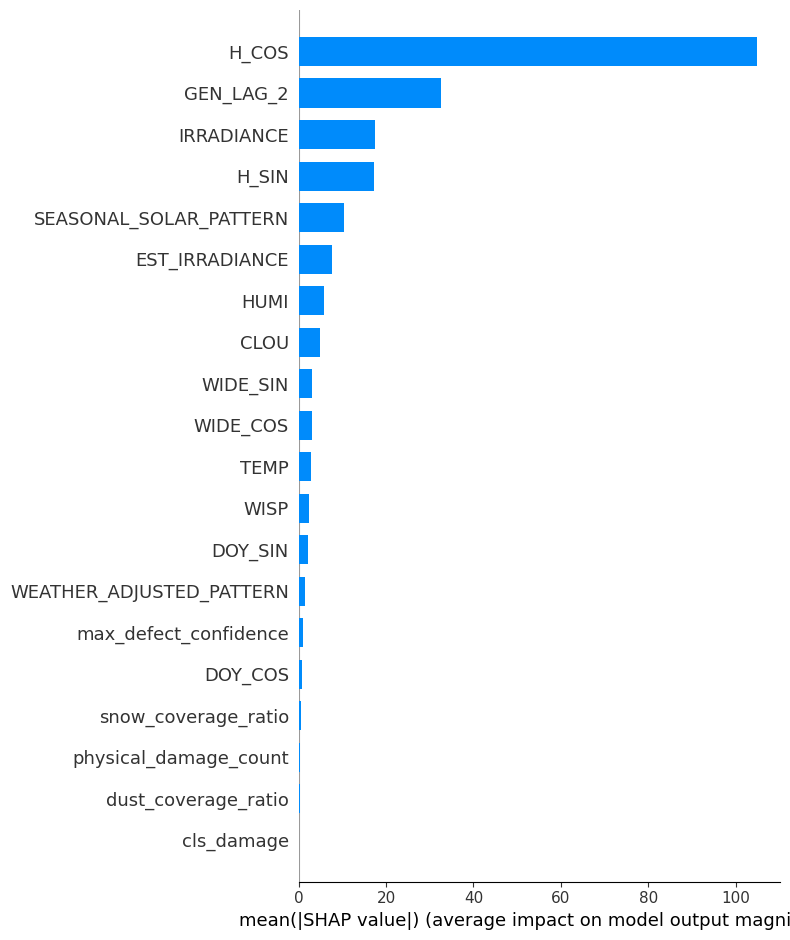

In [1366]:
# =========================
# XAI: SHAP 기반 Feature Importance
# =========================

import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_final)

# 전체 feature 중요도 bar plot
shap.summary_plot(
    shap_values,
    X_test_final,
    plot_type="bar"
)

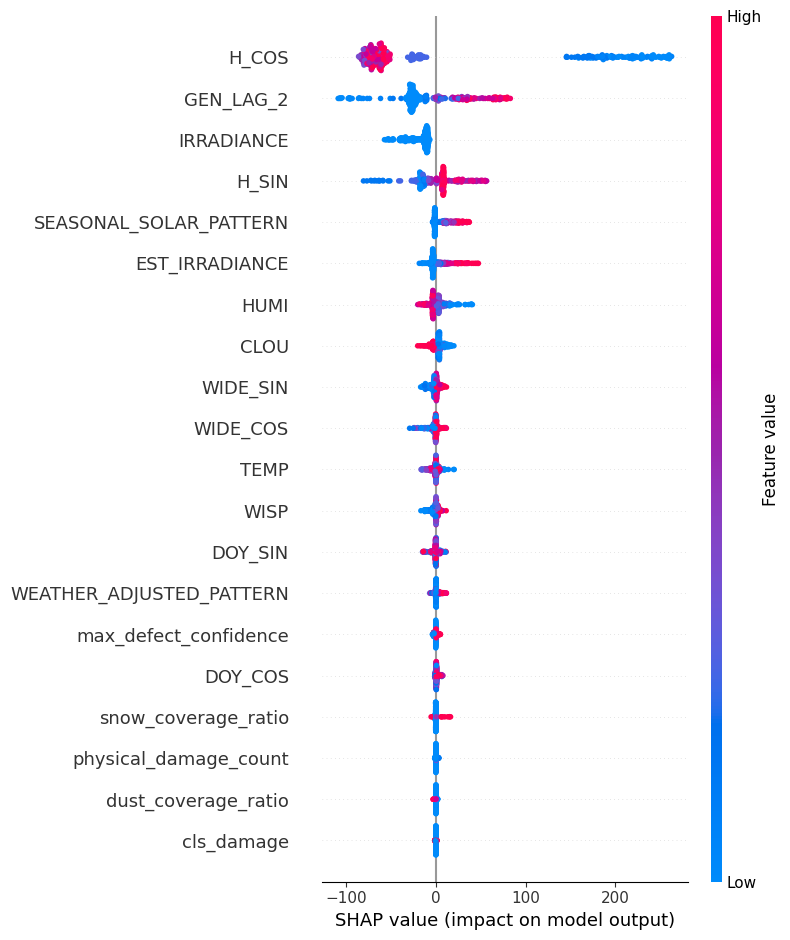

In [1367]:
# =========================
# XAI: SHAP Summary Plot
# =========================

shap.summary_plot(
    shap_values,
    X_test_final
)

선택된 이상 구간 index: 224
TIME: 2026-02-19 13:00:00
ACTUAL: 764.3699999999999
PREDICTION: 387.38852632646785
ERROR: 376.98147367353204


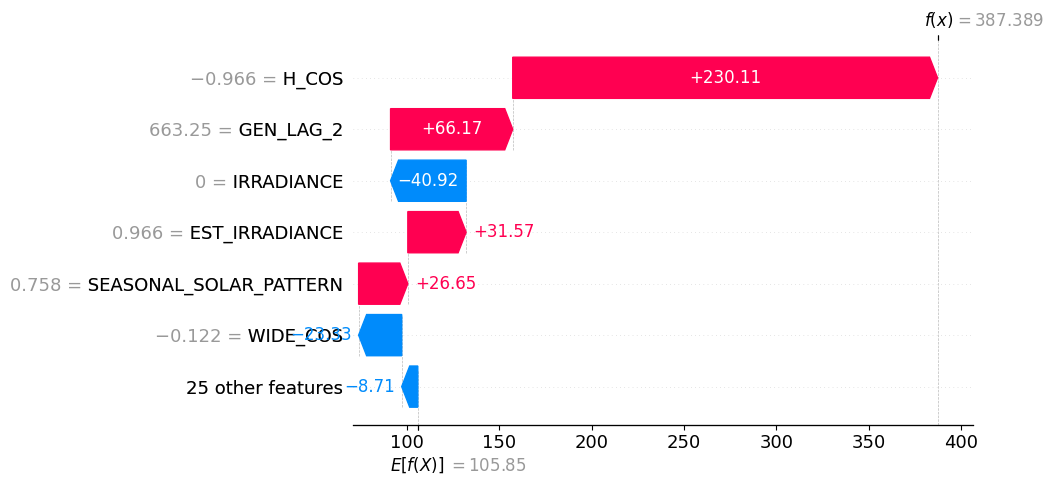

In [1368]:
# =========================
# XAI: 이상 구간 개별 예측 설명
# =========================

# ERROR가 가장 큰 이상 구간 선택
top_anomaly_idx = merged_df.sort_values("ERROR", ascending=False).index[0]

print("선택된 이상 구간 index:", top_anomaly_idx)
print("TIME:", merged_df.loc[top_anomaly_idx, "TIME"])
print("ACTUAL:", merged_df.loc[top_anomaly_idx, "ACTUAL"])
print("PREDICTION:", merged_df.loc[top_anomaly_idx, "PREDICTION"])
print("ERROR:", merged_df.loc[top_anomaly_idx, "ERROR"])

plt.figure(figsize=(12,8))

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[top_anomaly_idx],
        base_values=explainer.expected_value,
        data=X_test_final.iloc[top_anomaly_idx],
        feature_names=X_test_final.columns
    ),
    max_display=7
)

plt.savefig(
    "SolarWise_XAI_Waterfall.png",
    dpi=220,
    bbox_inches="tight"

)

In [1369]:
# =========================
# XAI: SHAP 중요도 저장
# =========================

import numpy as np
import pandas as pd

shap_importance_df = pd.DataFrame({
    "feature": X_test_final.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance_df.head(20))

shap_importance_df.to_csv(
    "wooyang_shap_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ wooyang_shap_feature_importance.csv 저장 완료")

,feature,mean_abs_shap
1,H_COS,104.860855
20,GEN_LAG_2,32.651948
12,IRRADIANCE,17.534373
0,H_SIN,17.319293
17,SEASONAL_SOLAR_PATTERN,10.295224
13,EST_IRRADIANCE,7.557263
5,HUMI,5.903369
6,CLOU,4.914552
8,WIDE_SIN,3.096204
9,WIDE_COS,3.039503


✅ wooyang_shap_feature_importance.csv 저장 완료


In [1370]:
# =========================
# 6. 평가 함수
# =========================

def evaluate_model(name, y_true, y_pred):
    y_true_arr = np.asarray(y_true).reshape(-1)
    y_pred_arr = np.asarray(y_pred).reshape(-1)

    mae = mean_absolute_error(y_true_arr, y_pred_arr)
    rmse = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
    r2 = r2_score(y_true_arr, y_pred_arr)
    nrmse = rmse / np.mean(y_true_arr)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "nRMSE": nrmse
    }

## 6. LightGBM 학습

In [1371]:
# =========================
# 7. LightGBM
# =========================
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from lightgbm import LGBMRegressor

    lgb_model = LGBMRegressor(
        objective="regression_l1", 
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=15,
        num_leaves=5,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=0.5,
        random_state=42,
        verbose=-1
    )

    lgb_model.fit(X_train_final, y_train)

    y_pred_lgb = lgb_model.predict(X_test_final)
    val_pred_lgb = lgb_model.predict(X_val_final)
    result_lgb = evaluate_model("LightGBM", y_test, y_pred_lgb)

    for key, value in result_lgb.items():
        print(f"{key}: {value}")

except ModuleNotFoundError:
    result_lgb = None
    y_pred_lgb = None
    print("LightGBM이 설치되어 있지 않습니다.")
    print("설치 코드: pip install lightgbm")

Model: LightGBM
MAE: 42.05659725311673
RMSE: 80.49321736573687
R2: 0.873553954282159
nRMSE: 0.5435334094995898


## 7. XGBoost 학습

In [1372]:
# =========================
# 8. XGBoost
# =========================

try:
    from xgboost import XGBRegressor

    xgb_model = XGBRegressor(
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        objective="reg:squarederror",
        eval_metric="rmse"
    )

    xgb_model.fit(X_train, y_train)

    y_pred_xgb = xgb_model.predict(X_test)
    result_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb)

    print(result_xgb)

except ModuleNotFoundError:
    result_xgb = None
    y_pred_xgb = None
    print("XGBoost가 설치되어 있지 않습니다.")
    print("설치 코드: pip install xgboost")

{'Model': 'XGBoost', 'MAE': 55.71430549043108, 'RMSE': np.float64(100.7382120558783), 'R2': 0.8019498589757086, 'nRMSE': np.float64(0.6802384804279338)}


## 8. LSTM 학습

데이터 수가 많지 않아 LSTM은 LightGBM/XGBoost보다 불리할 수 있습니다.  
그래도 비교 실험용으로 실행합니다.

In [1373]:
# =========================
# 9. LSTM
# =========================
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(np.array(y_train).reshape(-1, 1))
    y_test_scaled = scaler_y.transform(np.array(y_test).reshape(-1, 1))

    def create_sequences(X_arr, y_arr, time_steps=12):
        Xs, ys = [], []
        for i in range(len(X_arr) - time_steps):
            Xs.append(X_arr[i:i + time_steps])
            ys.append(y_arr[i + time_steps])
        return np.array(Xs), np.array(ys)

    time_steps = 12

    X_train_lstm, y_train_lstm = create_sequences(X_train_scaled, y_train_scaled, time_steps)
    X_test_lstm, y_test_lstm = create_sequences(X_test_scaled, y_test_scaled, time_steps)

    lstm_model = Sequential([
        LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    lstm_model.compile(optimizer="adam", loss="mae")

    lstm_model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=30,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )

    y_pred_lstm_scaled = lstm_model.predict(X_test_lstm)
    y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)
    y_test_lstm_actual = scaler_y.inverse_transform(y_test_lstm)

    result_lstm = evaluate_model("LSTM", y_test_lstm_actual, y_pred_lstm)

    print(result_lstm)

    # =========================
# 앙상블 모델
# =========================


except ModuleNotFoundError:
    result_lstm = None
    y_pred_lstm = None
    print("TensorFlow가 설치되어 있지 않습니다.")
    print("설치 코드: pip install tensorflow")

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.1418 - val_loss: 0.0658
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0743 - val_loss: 0.0481
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0598 - val_loss: 0.0473
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0596 - val_loss: 0.0474
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0543 - val_loss: 0.0489
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0518 - val_loss: 0.0751
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0506 - val_loss: 0.0495
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0488 - val_loss: 0.0544
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0501 - val_loss: 0.0465
Epoch 10/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0434 - val_loss: 0.0556
Epoch 11/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0472 - val_loss: 0.0629
Epoch 12/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0

In [1374]:
# =========================
# 앙상블 모델
# =========================

# LSTM 예측 길이에 맞추기
lstm_len = len(y_pred_lstm)

y_test_ens = np.array(y_test)[-lstm_len:]

y_pred_lgb_ens = np.array(y_pred_lgb)[-lstm_len:]
y_pred_xgb_ens = np.array(y_pred_xgb)[-lstm_len:]
y_pred_lstm_ens = np.array(y_pred_lstm).reshape(-1)

# 앙상블 1: LightGBM + LSTM
y_pred_ensemble_lgb_lstm = (y_pred_lgb_ens + y_pred_lstm_ens) / 2

# 앙상블 2: XGBoost + LSTM
y_pred_ensemble_xgb_lstm = (y_pred_xgb_ens + y_pred_lstm_ens) / 2

# 앙상블 3: 전체 평균
y_pred_ensemble_all = (
    y_pred_lgb_ens + y_pred_xgb_ens + y_pred_lstm_ens
) / 3

result_ensemble_lgb_lstm = evaluate_model(
    "Ensemble_LGBM_LSTM", y_test_ens, y_pred_ensemble_lgb_lstm
)

result_ensemble_xgb_lstm = evaluate_model(
    "Ensemble_XGB_LSTM", y_test_ens, y_pred_ensemble_xgb_lstm
)

result_ensemble_all = evaluate_model(
    "Ensemble_All", y_test_ens, y_pred_ensemble_all
)

print(result_ensemble_lgb_lstm)
print(result_ensemble_xgb_lstm)
print(result_ensemble_all)

{'Model': 'Ensemble_LGBM_LSTM', 'MAE': 87.30359577697175, 'RMSE': np.float64(165.89143725864957), 'R2': 0.47920786814383187, 'nRMSE': np.float64(1.107864824690195)}
{'Model': 'Ensemble_XGB_LSTM', 'MAE': 79.98055690030024, 'RMSE': np.float64(154.66286341150288), 'R2': 0.5473228557759648, 'nRMSE': np.float64(1.0328775788006157)}
{'Model': 'Ensemble_All', 'MAE': 46.44766532311447, 'RMSE': np.float64(97.14931125734518), 'R2': 0.8213940483785198, 'nRMSE': np.float64(0.6487875833945743)}


## 9. 성능 비교 및 최종 모델 선정

In [1375]:
# =========================
# 10. 모델 성능 비교 (앙상블 포함)
# =========================

results_list = [
    r for r in [
        result_lgb,
        result_xgb,
        result_lstm,
        result_ensemble_lgb_lstm,
        result_ensemble_xgb_lstm,
        result_ensemble_all,
    ]
    if r is not None
]

if len(results_list) == 0:
    raise ValueError("학습 완료된 모델이 없습니다.")

results = pd.DataFrame(results_list)

# RMSE 기준 추천 (태양광은 RMSE 중요)
results = results.sort_values("RMSE").reset_index(drop=True)

results

,Model,MAE,RMSE,R2,nRMSE
0,LightGBM,42.056597,80.493217,0.873554,0.543533
1,Ensemble_All,46.447665,97.149311,0.821394,0.648788
2,XGBoost,55.714305,100.738212,0.801950,0.680238
3,Ensemble_XGB_LSTM,79.980557,154.662863,0.547323,1.032878
4,Ensemble_LGBM_LSTM,87.303596,165.891437,0.479208,1.107865
5,LSTM,197.395181,368.740531,-1.573109,2.462542


In [1376]:
# =========================
# 🔥 Lag 제거 모델 (실서비스용)
# =========================

result_nl = None

from lightgbm import LGBMRegressor

# 1. df_model에 실제 존재하는 feature만 사용
missing_cols = [col for col in feature_cols if col not in df_model.columns]

print("df_model에 없는 컬럼 개수:", len(missing_cols))
print("df_model에 없는 컬럼:", missing_cols)

feature_cols_valid = [col for col in feature_cols if col in df_model.columns]

print("사용 가능한 feature 개수:", len(feature_cols_valid))
print(feature_cols_valid)

# 2. Lag / Rolling feature 찾기
lag_features = [
    col for col in feature_cols_valid
    if ("LAG" in col.upper()) or ("ROLL" in col.upper())
]

print("제거할 lag/rolling feature 개수:", len(lag_features))
print("제거할 lag/rolling feature:", lag_features)

# 3. Lag / Rolling 제거 feature 생성
feature_cols_no_lag = [
    col for col in feature_cols_valid
    if col not in lag_features
]

print("lag 제거 후 feature 개수:", len(feature_cols_no_lag))
print(feature_cols_no_lag)

# 4. 데이터 생성
X_no_lag = df_model[feature_cols_no_lag]
y_no_lag = df_model[target_col]

# 5. 동일 split 유지
X_train_nl = X_no_lag.iloc[:split_idx]
X_test_nl = X_no_lag.iloc[split_idx:]

y_train_nl = y_no_lag.iloc[:split_idx]
y_test_nl = y_no_lag.iloc[split_idx:]

# 6. 모델 학습
lgb_model_nl = LGBMRegressor(
    random_state=42,
    objective="regression_l1"
)

lgb_model_nl.fit(X_train_nl, y_train_nl)

# 7. 예측
y_pred_nl = lgb_model_nl.predict(X_test_nl)

# 8. 평가
result_nl = evaluate_model("LightGBM_NO_LAG", y_test_nl, y_pred_nl)

print(result_nl)

df_model에 없는 컬럼 개수: 16
df_model에 없는 컬럼: ['PCP_MM', 'PCP_6H', 'SNO_24H', 'POP_PCT', 'N_MISSING', 'MISS_TEMP', 'MISS_CLOU', 'MISS_WISP', 'MISS_WIDE', 'MISS_ASOS_ANY', 'CLEARNESS_PROXY', 'GEN_NORMAL_PATTERN', 'GEN_LAG_1', 'GEN_LAG_3', 'GEN_ROLL_MEAN_3', 'GEN_ROLL_MEAN_6']
사용 가능한 feature 개수: 21
['H_SIN', 'H_COS', 'DOY_SIN', 'DOY_COS', 'TEMP', 'HUMI', 'CLOU', 'WISP', 'WIDE_SIN', 'WIDE_COS', 'SUN_ELEV_CLIP', 'COS_ZEN', 'CAPA', 'IRRADIANCE_PROXY', 'EST_IRRADIANCE', 'IRRADIANCE_X_CAPA', 'SEASONAL_SOLAR_PATTERN', 'WEATHER_ADJUSTED_PATTERN', 'EXPECTED_GEN_PROXY', 'IRRADIANCE', 'GEN_LAG_2']
제거할 lag/rolling feature 개수: 1
제거할 lag/rolling feature: ['GEN_LAG_2']
lag 제거 후 feature 개수: 20
['H_SIN', 'H_COS', 'DOY_SIN', 'DOY_COS', 'TEMP', 'HUMI', 'CLOU', 'WISP', 'WIDE_SIN', 'WIDE_COS', 'SUN_ELEV_CLIP', 'COS_ZEN', 'CAPA', 'IRRADIANCE_PROXY', 'EST_IRRADIANCE', 'IRRADIANCE_X_CAPA', 'SEASONAL_SOLAR_PATTERN', 'WEATHER_ADJUSTED_PATTERN', 'EXPECTED_GEN_PROXY', 'IRRADIANCE']
{'Model': 'LightGBM_NO_LAG', 'MAE': 86

In [1377]:
# =========================
# 🔥 Lag 제거 + 일사량 추가 모델
# =========================

result_nli = None

from lightgbm import LGBMRegressor

# 1. df_model에 실제 존재하는 feature만 사용
feature_cols_valid = [col for col in feature_cols if col in df_model.columns]

missing_cols = [col for col in feature_cols if col not in df_model.columns]
print("df_model에 없는 컬럼 개수:", len(missing_cols))
print("df_model에 없는 컬럼:", missing_cols)

# 2. Lag / Rolling feature 제거
lag_features = [
    col for col in feature_cols_valid
    if ("LAG" in col.upper()) or ("ROLL" in col.upper())
]

feature_cols_no_lag = [
    col for col in feature_cols_valid
    if col not in lag_features
]

# 3. IRRADIANCE 추가
if "IRRADIANCE" in df_model.columns:
    if "IRRADIANCE" not in feature_cols_no_lag:
        feature_cols_no_lag.append("IRRADIANCE")
else:
    print("⚠️ IRRADIANCE 컬럼이 df_model에 없습니다. 일사량 없이 진행합니다.")

# 4. 최종적으로 한 번 더 존재 컬럼만 필터링
feature_cols_no_lag = [col for col in feature_cols_no_lag if col in df_model.columns]

print("제거할 lag/rolling feature 개수:", len(lag_features))
print("제거할 lag/rolling feature:", lag_features)

print("최종 feature 개수:", len(feature_cols_no_lag))
print(feature_cols_no_lag)

# 5. 데이터 구성
X_no_lag_irr = df_model[feature_cols_no_lag]
y_no_lag_irr = df_model[target_col]

# 6. 동일 split 유지
X_train_nli = X_no_lag_irr.iloc[:split_idx]
X_test_nli = X_no_lag_irr.iloc[split_idx:]

y_train_nli = y_no_lag_irr.iloc[:split_idx]
y_test_nli = y_no_lag_irr.iloc[split_idx:]

# 7. 모델 학습
lgb_model_nli = LGBMRegressor(
    random_state=42,
    objective="regression_l1"
)

lgb_model_nli.fit(X_train_nli, y_train_nli)

# 8. 예측
y_pred_nli = lgb_model_nli.predict(X_test_nli)

# 9. 평가
result_nli = evaluate_model("LightGBM_NO_LAG_IRRADIANCE", y_test_nli, y_pred_nli)

print(result_nli)

df_model에 없는 컬럼 개수: 16
df_model에 없는 컬럼: ['PCP_MM', 'PCP_6H', 'SNO_24H', 'POP_PCT', 'N_MISSING', 'MISS_TEMP', 'MISS_CLOU', 'MISS_WISP', 'MISS_WIDE', 'MISS_ASOS_ANY', 'CLEARNESS_PROXY', 'GEN_NORMAL_PATTERN', 'GEN_LAG_1', 'GEN_LAG_3', 'GEN_ROLL_MEAN_3', 'GEN_ROLL_MEAN_6']
제거할 lag/rolling feature 개수: 1
제거할 lag/rolling feature: ['GEN_LAG_2']
최종 feature 개수: 20
['H_SIN', 'H_COS', 'DOY_SIN', 'DOY_COS', 'TEMP', 'HUMI', 'CLOU', 'WISP', 'WIDE_SIN', 'WIDE_COS', 'SUN_ELEV_CLIP', 'COS_ZEN', 'CAPA', 'IRRADIANCE_PROXY', 'EST_IRRADIANCE', 'IRRADIANCE_X_CAPA', 'SEASONAL_SOLAR_PATTERN', 'WEATHER_ADJUSTED_PATTERN', 'EXPECTED_GEN_PROXY', 'IRRADIANCE']


{'Model': 'LightGBM_NO_LAG_IRRADIANCE', 'MAE': 86.82893655587444, 'RMSE': np.float64(180.81814144510443), 'R2': 0.3345377633973289, 'nRMSE': np.float64(1.3395523816809682)}


In [1378]:
compare_no_lag = pd.DataFrame([
    
    result_nli
]).sort_values("RMSE").reset_index(drop=True)

compare_no_lag

,Model,MAE,RMSE,R2,nRMSE
0,LightGBM_NO_LAG_IRRADIANCE,86.828937,180.818141,0.334538,1.339552


In [1379]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor

def evaluate_model(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = LGBMRegressor(random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    nrmse = rmse / (y_test.max() - y_test.min())

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "nRMSE": nrmse
    }

results = []

results.append(evaluate_model(X, y, "Final_Feature_23"))

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2,nRMSE
0,Final_Feature_23,40.971632,79.488087,0.874077,0.103343


In [1380]:
# =========================
# 🔥 병합 CSV 생성 (최종 전달용)
# =========================

# 1. test feature 복사
merged_df = X_test.copy()

# 2. TIME 추가
merged_df.insert(0, "TIME", time_test.values)

# 3. 예측값 추가
merged_df["PREDICTION"] = y_pred_lgb

# 4. (선택) 실제값도 같이 넣기
merged_df["ACTUAL"] = y_test.values

# 5. 저장
merged_df.to_csv(
    "wooyang_merged_result.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ wooyang_merged_result.csv 저장 완료")
print(merged_df.head())

✅ wooyang_merged_result.csv 저장 완료
                    TIME     H_SIN         H_COS  DOY_SIN   DOY_COS  TEMP  \
3307 2026-02-10 05:00:00  0.965926  2.588190e-01  0.64863  0.761104 -0.62   
3308 2026-02-10 06:00:00  1.000000  6.123234e-17  0.64863  0.761104 -1.05   
3309 2026-02-10 07:00:00  0.965926 -2.588190e-01  0.64863  0.761104 -0.88   
3310 2026-02-10 08:00:00  0.866025 -5.000000e-01  0.64863  0.761104 -0.82   
3311 2026-02-10 09:00:00  0.707107 -7.071068e-01  0.64863  0.761104 -0.36   

      HUMI   CLOU  WISP  WIDE_SIN  ...  EST_IRRADIANCE  IRRADIANCE_PROXY  \
3307  72.0  100.0  1.55  0.190809  ...        0.000000          0.000000   
3308  80.0   75.0  2.36  0.292372  ...        0.000000          0.000000   
3309  79.0   80.0  2.41  0.422618  ...        0.051764          0.258819   
3310  82.0   85.0  2.41  0.766044  ...        0.075000          0.500000   
3311  80.0   90.0  2.18  0.927184  ...        0.070711          0.707107   

      IRRADIANCE_X_CAPA     CAPA  SEASONAL_SOL

In [1381]:
print(len(feature_cols_23))

21


In [1382]:
print("컬럼 개수:", len(merged_df.columns))
print(merged_df.columns.tolist())

컬럼 개수: 24
['TIME', 'H_SIN', 'H_COS', 'DOY_SIN', 'DOY_COS', 'TEMP', 'HUMI', 'CLOU', 'WISP', 'WIDE_SIN', 'WIDE_COS', 'SUN_ELEV_CLIP', 'COS_ZEN', 'IRRADIANCE', 'EST_IRRADIANCE', 'IRRADIANCE_PROXY', 'IRRADIANCE_X_CAPA', 'CAPA', 'SEASONAL_SOLAR_PATTERN', 'WEATHER_ADJUSTED_PATTERN', 'EXPECTED_GEN_PROXY', 'GEN_LAG_2', 'PREDICTION', 'ACTUAL']


In [1383]:
# =========================
# 최종 31개 feature 병합 CSV 생성
# =========================

# 1. 최종 feature 데이터 복사
merged_df_31 = X_test_final.copy()

# 2. TIME 추가
merged_df_31.insert(0, "TIME", time_test.values)

# 3. 예측값 추가
merged_df_31["PREDICTION"] = y_pred_lgb

# 4. 실제값 추가
merged_df_31["ACTUAL"] = y_test.values

# 5. 확인
print("컬럼 개수:", len(merged_df_31.columns))
print(merged_df_31.columns.tolist())

# 6. 저장
merged_df_31.to_csv(
    "wooyang_merged_result_31feature.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ wooyang_merged_result_31feature.csv 저장 완료")

컬럼 개수: 34
['TIME', 'H_SIN', 'H_COS', 'DOY_SIN', 'DOY_COS', 'TEMP', 'HUMI', 'CLOU', 'WISP', 'WIDE_SIN', 'WIDE_COS', 'SUN_ELEV_CLIP', 'COS_ZEN', 'IRRADIANCE', 'EST_IRRADIANCE', 'IRRADIANCE_PROXY', 'IRRADIANCE_X_CAPA', 'CAPA', 'SEASONAL_SOLAR_PATTERN', 'WEATHER_ADJUSTED_PATTERN', 'EXPECTED_GEN_PROXY', 'GEN_LAG_2', 'dust_coverage_ratio', 'snow_coverage_ratio', 'bird_dropping_count', 'physical_damage_count', 'max_defect_confidence', 'cls_normal', 'cls_dust', 'cls_snow', 'cls_bird', 'cls_damage', 'PREDICTION', 'ACTUAL']
✅ wooyang_merged_result_31feature.csv 저장 완료


In [1384]:
merged_df.columns

Index(['TIME', 'H_SIN', 'H_COS', 'DOY_SIN', 'DOY_COS', 'TEMP', 'HUMI', 'CLOU',
       'WISP', 'WIDE_SIN', 'WIDE_COS', 'SUN_ELEV_CLIP', 'COS_ZEN',
       'IRRADIANCE', 'EST_IRRADIANCE', 'IRRADIANCE_PROXY', 'IRRADIANCE_X_CAPA',
       'CAPA', 'SEASONAL_SOLAR_PATTERN', 'WEATHER_ADJUSTED_PATTERN',
       'EXPECTED_GEN_PROXY', 'GEN_LAG_2', 'PREDICTION', 'ACTUAL'],
      dtype='object')

In [1385]:
irr_cols = [col for col in merged_df.columns if "IRRADIANCE" in col]
print(irr_cols)

['IRRADIANCE', 'EST_IRRADIANCE', 'IRRADIANCE_PROXY', 'IRRADIANCE_X_CAPA']


In [1386]:
# =========================
# 11. 최종 모델 선정
# =========================

best_model_name = results_df.iloc[0]["Model"]

print("최종 선정 모델:", best_model_name)
print(results_df.iloc[0])

최종 선정 모델: Final_Feature_23
Model    Final_Feature_23
MAE             40.971632
RMSE            79.488087
R2               0.874077
nRMSE            0.103343
Name: 0, dtype: object


In [1387]:
print("train NaN:", X_train_final.isna().sum().sum())
print("val NaN:", X_val_final.isna().sum().sum())
print("test NaN:", X_test_final.isna().sum().sum())
print("train:", X_train_final.shape, y_train.shape)
print("val:", X_val_final.shape, y_val.shape)
print("test:", X_test_final.shape, y_test.shape)

train NaN: 0
val NaN: 0
test NaN: 0
train: (2898, 31) (2898,)
val: (409, 31) (409,)
test: (333, 31) (333,)


In [1388]:
print(X_test.shape)

(333, 21)


## 10. Feature Importance

트리 기반 모델 중 LightGBM이 실행된 경우 feature importance를 확인합니다.

In [1389]:
# =========================
# 12. Feature Importance
# =========================

if result_lgb is not None:
    importance_df = pd.DataFrame({
        "feature": X_train_final.columns,
        "importance": lgb_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importance_df.head(20))
else:
    print("LightGBM 결과가 없어 feature importance를 표시할 수 없습니다.")

,feature,importance
0,H_SIN,732
20,GEN_LAG_2,548
12,IRRADIANCE,414
2,DOY_SIN,410
1,H_COS,285
18,WEATHER_ADJUSTED_PATTERN,240
13,EST_IRRADIANCE,221
7,WISP,166
4,TEMP,163
3,DOY_COS,134


## 11. 예측 결과 저장

In [1390]:
# =========================
# 13. 예측 결과 저장
# =========================

pred_df = pd.DataFrame({
    "TIME": time_test.reset_index(drop=True),
    "Actual": y_test.reset_index(drop=True),
})

if y_pred_lgb is not None:
    pred_df["Pred_LightGBM"] = y_pred_lgb

if y_pred_xgb is not None:
    pred_df["Pred_XGBoost"] = y_pred_xgb

# LSTM은 time_steps만큼 테스트 앞부분이 빠지므로 별도 저장
if result_lstm is not None:
    lstm_pred_df = pd.DataFrame({
        "TIME": time_test.iloc[time_steps:].reset_index(drop=True),
        "Actual": y_test_lstm_actual.reshape(-1),
        "Pred_LSTM": y_pred_lstm.reshape(-1)
    })
    lstm_pred_df.to_csv("wooyang_lstm_prediction_result.csv", index=False, encoding="utf-8-sig")

pred_df.to_csv("wooyang_prediction_result.csv", index=False, encoding="utf-8-sig")
results_df.to_csv("wooyang_model_comparison.csv", index=False, encoding="utf-8-sig")

print("저장 완료:")
print("- wooyang_prediction_result.csv")
print("- wooyang_model_comparison.csv")
if result_lstm is not None:
    print("- wooyang_lstm_prediction_result.csv")

pred_df.head()

저장 완료:
- wooyang_prediction_result.csv
- wooyang_model_comparison.csv
- wooyang_lstm_prediction_result.csv


,TIME,Actual,Pred_LightGBM,Pred_XGBoost
0,2026-02-10 05:00:00,0.00,0.000010,0.180305
1,2026-02-10 06:00:00,0.00,-0.006504,-1.061451
2,2026-02-10 07:00:00,1.61,11.634722,-5.565194
3,2026-02-10 08:00:00,32.78,66.502793,68.245232
4,2026-02-10 09:00:00,148.67,185.075926,162.638657


In [1391]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(2898, 21)
(409, 21)
(333, 21)


In [1392]:
import pandas as pd

panel_train = pd.read_csv("panel_features_train.csv")
panel_val = pd.read_csv("panel_features_val.csv")
panel_test = pd.read_csv("panel_features_test.csv")

print(panel_train.shape)
print(panel_val.shape)
print(panel_test.shape)

(2898, 11)
(409, 11)
(333, 11)


In [1393]:
print(panel_train["image"].head())

0    1-10-_jpg.rf.4c2db0f05c823f19f26f91dfde6e0130.jpg
1    1-100-_jpg.rf.05ad637368518c4accfbcd09c0645f6e...
2    1-100-_jpg.rf.249cfc5a3a5ced7f330bd1965ae8792e...
3    1-100-_jpg.rf.efb7fea4ca4d08c2f2fac9ce69ee9dc6...
4    1-102-_jpg.rf.5b090b64fbfcd73e26307016037cf9bd...
Name: image, dtype: object


In [1394]:
print(df["TIME"].min(), df["TIME"].max(), len(df))
print(merged_df_31["TIME"].min(), merged_df_31["TIME"].max(), len(merged_df_31))

2025-09-25 10:00:00 2026-04-26 23:00:00 5126
2026-02-10 05:00:00 2026-02-24 01:00:00 333


## 12. 모델 저장

성능 비교 후 최종 모델만 저장해도 됩니다.  
아래 코드는 실행된 모델을 모두 저장합니다.

In [1395]:
# =========================
# 14. 모델 저장
# =========================

import joblib

if result_lgb is not None:
    joblib.dump(lgb_model, "wooyang_lightgbm_model_final.pkl")

if result_xgb is not None:
    joblib.dump(xgb_model, "wooyang_xgboost_model.pkl")

if result_lstm is not None:
    lstm_model.save("wooyang_lstm_model.h5")

print("모델 저장 완료")

모델 저장 완료
